参数高效微调

In [ ]:
#挂载谷歌云盘，挂载就是将另外一个系统的硬盘，映射到当前电脑上
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#谷歌云盘的数据都在这里
!ls /content/drive/MyDrive/

 AdvertiseGen_fix
 alpaca-lora
 ChatGLM3
 chatglm3-6b
 ChatGLM-6B
 chatglm_finetuning-dev
 ChatGLM-Finetuning-master
 checkpoints
 cifar-10
'Colab Notebooks'
 deepfm.png
 deepseek-r1
 detr_demo-da2a99e9.pth
 din.png
 finetune_speaker.json
 GLM-4
 GLM4大模型LoRA微调代码
 GLM4大模型微调代码
 grpo_finetuned_model
 imdb_processed.csv
 Lerobot数据到Qwen2.5-VL的整合示例
'Lerobot数据到Qwen2.5-VL的整合示例 (1)'
 models
 models--bert-base-uncased
 NeuralCF.png
 requirement.txt
 SadTalker
 sampledata
 saved_models
 sst2
'Stable Diffusion 文生图 Python 脚本'
'Stable Diffusion 文生图 Python 脚本（含模型结构打印）'
 tensorflow1
 tloen-alpaca-lora
 transformer-de-en
 videos
 voice_data
 widedeep.png


In [ ]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
#sst2就是情感分类的数据集，二分类的
!ls sst2

data  README.md


#阿里云运行本代码时，上面的内容可以删掉，直接把sst2文件夹和jupyter代码文件放在同一个路径

In [ ]:
!pip install datasets==2.20.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 28.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.5.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [ ]:
!pip list|grep datasets

datasets                              2.20.0
tensorflow-datasets                   4.9.9
vega-datasets                         0.9.0


In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoConfig, AutoModel, get_cosine_schedule_with_warmup

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from tqdm.auto import tqdm

# 固定seed
torch.manual_seed(42)
# 确定设备：如果有GPU可用则使用GPU，否则使用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#如果GPU可以，可以改为20
num_epochs = 5
patience = 5

training_record = {}

## preparation

SST-2（Stanford Sentiment Treebank）是斯坦福大学发布的一个用于情感分析的数据集，旨在对句子的情感进行分类。该数据集中包含电影评论句子，每个句子都带有相应的情感标签。情感标签分为两类：正面（positive）和负面（negative），因此 SST-2 是一个二分类任务的数据集。

Positive（正面）：

"The movie was absolutely fantastic."（这部电影绝对太棒了。）
"I loved the acting and the storyline."（我喜欢演技和故事情节。）

Negative（负面）：

"The film was a complete disaster."（这部电影完全是个灾难。）
"The acting was terrible, I wouldn't recommend it."（演技糟糕，我不推荐这部电影。）

### load dataset

In [ ]:
# https://huggingface.co/google-bert/bert-base-uncased

# 加载BERT的分词器（tokenizer），uncased 表示不区分大小写
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 加载本地SST-2情感分类数据集，文件格式为parquet
# 数据集分为训练集和验证集
dataset_sst2 = load_dataset(
    "parquet",  # 指定文件格式
    data_files={
        "train": "./sst2/data/train-00000-of-00001.parquet",           # 训练集文件路径
        "validation": "./sst2/data/validation-00000-of-00001.parquet"  # 验证集文件路径
    }
)

# 定义用于DataLoader的自定义collate_fn函数，将原始batch加工为模型输入
def collate_fn(batch):
    # 提取batch中的句子字符串，组成一个列表
    sentences = [x["sentence"] for x in batch]
    # 使用tokenizer对句子进行分词编码
    # padding="longest"：对batch中句子按最长句子对齐补零
    # truncation=True：如句子超长则截断
    # return_tensors="pt"：输出为PyTorch tensor
    # max_length=512：最长支持到512个token
    inputs = tokenizer(
        sentences, 
        padding="longest", 
        truncation=True, 
        return_tensors="pt", 
        max_length=512
    )
    # 提取标签，转换为long类型的Tensor
    labels = torch.tensor([x["label"] for x in batch])
    # 返回模型直接可用的inputs字典和labels
    return inputs, labels

# 构建训练集的DataLoader
# batch_size=32，每个batch 32条数据
# shuffle=True，训练时打乱顺序
# 使用自定义collate_fn
train_loader = DataLoader(
    dataset_sst2["train"], 
    batch_size=32, 
    shuffle=True, 
    collate_fn=collate_fn
)
# 构建验证集的DataLoader
# batch_size=32
# 不需要shuffle
val_loader = DataLoader(
    dataset_sst2["validation"], 
    batch_size=32, 
    collate_fn=collate_fn
)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

In [ ]:
len(dataset_sst2["train"])

67349

In [ ]:
# 遍历 DataLoader 中的一个批次示例（用于查看每个批次的数据结构和内容）
for inputs, label in train_loader:
    # 打印当前 batch 第0个样本的 input_ids（即分词后的token id序列）
    print(inputs['input_ids'][0])
    # 打印当前 batch 第1个样本的 input_ids
    print(inputs['input_ids'][1])
    # 打印 attention_mask 的形状
    # 说明:
    #   - 这里的形状为 (32, 33)
    #   - 第一个维度 32 表示 batch_size 为32，每批有32条样本
    #   - 第二个维度 33 表示本批次里最长的句子分成了33个token（含[CLS]/[SEP]等特殊标记）
    #   - DataLoader 通过 collate_fn（padding="longest"）把所有句子都pad到了本批次最长的句子长度（33）
    #   - 这样，所有 input_ids、attention_mask、token_type_ids 形状都一样，便于张量运算
    print(inputs['attention_mask'].shape)
    
    print(inputs['attention_mask'][0])  # 打印第0个样本的 attention_mask 实际值
    # 答疑：BERT/BERT-like 模型中，这里的 attention_mask 通常只有 padding mask，
    # 即：1 代表 real token，0 代表 padding（非真实token）。
    # 主要作用：让模型在自注意力/编码阶段“忽略”被 pad 的那些位置，不影响句子真实表达。
    # 一般来说，除了 padding，attention_mask 不包含其它 mask（比如 causal mask），
    # 因为 BERT 是双向注意力，不像 GPT 需要未来 masked。
    print(inputs['token_type_ids'][0])  # 打印第0个样本的token_type_ids
    print(label)  # 打印当前 batch 的标签张量
    break  # 只查看第一个batch，避免输出过多

tensor([ 101, 2062, 8669, 1010, 2062, 6832,  102,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0])
tensor([  101,  2009,  1005,  1055, 10889, 11519,  1010,  3391,  2005,  1037,
         7891, 18932,  1999,  1037,  2186,  1012,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0])
torch.Size([32, 33])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 1])


### define evaluattion and training function

In [ ]:
# 这行代码的作用是将当前虚拟环境中已安装的所有Python包及其版本号输出到requirement.txt文件中
# 这样可以方便后续复现环境，或在其它地方通过 pip install -r requirement.txt 一次性安装相同依赖
!pip freeze >requirement.txt

In [ ]:
def evaluate(model, val_loader):
    """
    评估模型在验证集上的性能，返回验证集损失和准确率。

    参数:
    model: 被评估的模型（需支持与输入张量字典交互）
    val_loader: 验证集 DataLoader，输出(batch_inputs, batch_labels)

    返回:
    val_loss: 验证集平均损失
    val_acc: 验证集平均准确率
    """
    model.eval()  # 设置为评估模式（影响dropout/batchnorm等层的行为）
    val_loss = 0  # 累加验证损失
    val_acc = 0   # 累加准确样本数
    # 在评估过程中关闭梯度计算，减少显存占用，加快推理速度
    with torch.no_grad():
        total_samples = 0  # 统计总样本数
        for inputs, labels in val_loader:
            # 将所有输入tensor移到目标device（如cuda）
            inputs = {k: v.to(device) for k, v in inputs.items()}  # 字典批量解包并送GPU
            labels = labels.to(device)
            # 前向传播获得预测概率 (probs)，一般返回 shape: (batch_size,)
            probs = model(**inputs)
            # 计算损失（二分类交叉熵），labels需转换为float型
            loss = F.binary_cross_entropy(probs, labels.float())
            val_loss += loss.item()  # 记录本batch损失
            # 准确率统计：预测概率大于0.5视为正类，与真实标签做比较
            val_acc += ((probs > 0.5) == labels).sum().item()
            total_samples += len(labels)  # 累计本batch样本数

    # 平均损失：所有batch损失和/batch数
    val_loss /= len(val_loader)
    # 平均准确率：所有预测正确样本数/总样本数
    val_acc /= total_samples
    return val_loss, val_acc


def train(model, train_loader, val_loader, device, num_epochs=3, patience=3):
    """
    完整的模型训练+评估主循环，包含早停机制与训练过程记录。

    参数:
    model: 被训练的PyTorch模型
    train_loader: 训练集 DataLoader
    val_loader: 验证集 DataLoader
    device: 计算设备（'cuda'或'cpu'）
    num_epochs: 最多训练轮数
    patience: 连续多少轮val_acc未提升则早停

    返回:
    history: dict，记录每一轮的train/val损失及准确率
    """
    model.to(device)  # 将模型权重参数送到目标device

    # 优化器，AdamW比Adam更适合transformers，支持去耦权重衰减
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

    # 计算训练过程中总的step数（1 step = 1 minibatch）
    total_steps = num_epochs * len(train_loader)

    # 创建余弦退火+warmup的调度器（适应transformers等大模型训练习惯）
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.2 * total_steps),  # 前20%步，学习率线性上升
        num_training_steps=total_steps           # 总训练步
    )

    # early stopping相关变量
    best_val_acc = -1  # 记录最佳val_acc
    cur = 0            # 没有提升的epoch计数器

    # 训练过程记录字典
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()  # 切换为训练模式
        train_loss = 0   # 当前epoch累计损失
        train_acc = 0    # 当前epoch累计准确数
        total_samples = 0  # 当前epoch累计样本数

        # 批量遍历训练集
        for inputs, labels in tqdm(train_loader):
            # 数据搬运到device
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)

            # 梯度归零（每次优化前都要）
            optimizer.zero_grad()
            # 前向传播计算输出概率
            probs = model(**inputs)  # 字典解包
            # 计算二分类交叉熵损失
            # 二分类交叉熵损失的计算过程如下：
            # 假设probs是模型对每个样本预测为正类（标签为1）的概率，labels是每个样本的真实标签（0或1）。
            # 对每个样本，损失= -[y*log(p) + (1-y)*log(1-p)]，其中y为标签，p为预测概率。
            # F.binary_cross_entropy 会自动对一个batch里的所有样本求平均，返回这个batch的平均损失。
            loss = F.binary_cross_entropy(probs, labels.float())
            # 反向传播计算梯度
            loss.backward()
            # 参数更新
            optimizer.step()
            # 调度器调整学习率
            scheduler.step()

            # 记录训练损失
            train_loss += loss.item()
            # 记录本batch中预测正确的样本数量
            train_acc += ((probs > 0.5) == labels).sum().item()
            total_samples += len(labels)

        # 每个epoch的train loss,train acc平均
        train_loss /= len(train_loader)
        train_acc  /= total_samples

        # 评估本epoch模型在验证集（不启用梯度）表现
        val_loss, val_acc = evaluate(model, val_loader)

        # 记录训练与验证过程指标并print
        print(f"epoch {epoch}: train_loss {train_loss:.4f}, train_acc {train_acc:.4f}, val_loss {val_loss:.4f}, val_acc {val_acc:.4f}")
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Early Stopping：如果有提升则刷新最佳acc，否则cur+1
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            cur = 0
        else:
            cur += 1
        # 若patience次连续无提升，则提前终止训练
        if cur >= patience:
            print("提前停止训练")
            break

    return history

### a function to check the parameters that could be fintuned

In [ ]:
def human_readable_count(n):
    """
    将数字 n 转换为更可读的格式：xxx、xxxK、xxxM、xxxB。
    例如：
      1500 -> 1.50K
      2_300_000 -> 2.30M
      1_700_000_000 -> 1.70B
    参数:
        n (int): 需要格式化的数字
    返回:
        str: 可读性更强的字符串表示
    """
    if n < 1_000:
        # 小于1千，直接输出原数
        return f"{n}"
    elif n < 1_000_000:
        # 千到百万之间，保留两位小数，以K(千)为单位
        return f"{n/1_000:.2f}K"
    elif n < 1_000_000_000:
        # 百万到十亿之间，保留两位小数，以M(百万)为单位
        return f"{n/1_000_000:.2f}M"
    else:
        # 大于十亿，保留两位小数，以B(十亿)为单位
        return f"{n/1_000_000_000:.2f}B"

def count_parameters(model):
    """
    统计并打印模型的参数总数、可训练参数数、冻结参数数及比例。
    参数:
        model (nn.Module): 需要统计参数的PyTorch模型
    """
    # 计算模型参数总数
    total_params = sum(p.numel() for p in model.parameters())
    # 计算模型中可训练（需要梯度）参数数量
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    # 计算模型冻结（不需要梯度）参数数量
    frozen_params = total_params - trainable_params

    # 打印模型参数总数，并用human_readable_count格式化输出
    print(f"Total Parameters:\t{human_readable_count(total_params):>8}")  # 总参数数量
    # 打印冻结参数数量
    print(f"Frozen Parameters:\t{human_readable_count(frozen_params):>8}")  # 冻结参数数量
    # 打印可训练参数数量，以及所占总参数的百分比
    print(f"Trainable Parameters:\t{human_readable_count(trainable_params):>8}\t{trainable_params / total_params:.2%}")  # 可训练参数数量及比例

In [ ]:
import matplotlib.pyplot as plt  # 导入用于绘图的matplotlib库

def plot_training_record(training_record, metric_name="val_acc"):
    """
    绘制训练过程中的某项性能指标变化曲线

    参数:
        training_record (dict): 包含训练记录的字典。每个键为方法名称（如"Frozen"），每个值为记录的字典（包含'metric_name'对应的数值列表）。
        metric_name (str): 指定要绘制的性能指标名称，默认为"val_acc"（验证集准确率）。

    返回:
        无（直接展示图表）
    """
    plt.figure(figsize=(12, 6))  # 创建一个大小为12x6英寸的绘图窗口
    # 遍历每个方法的训练记录，对每个方法分别生成一条折线
    for method_name, record in training_record.items():  # method_name是方法名称（如Frozen），record是其对应的指标记录字典
        metrics = record[metric_name]  # 取出该方法下metric_name的所有数值（如所有轮次的val_acc）
        plt.plot(range(len(metrics)), metrics, label=method_name)  # 画出x为轮次（epoch），y为metric数值的折线，并设置图例

    plt.xlabel("Epoch")  # 设置横轴标签为"Epoch"（训练轮次）
    plt.ylabel("Validation Accuracy")  # 设置纵轴标签，此处假定metric_name是val_acc，可自定义
    plt.legend()  # 显示不同方法的图例，便于辨识
    plt.grid()  # 启用网格线，使图表更易于阅读
    plt.show()  # 展示图表窗口

In [ ]:
#bert-base-uncased的uncased不区分大小写的意思
bert_model=AutoModel.from_pretrained("bert-base-uncased")
print(bert_model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

## A Frozen pretrained Bert as a feature extractor  将预训练过的Bert冻结作为特征提取器

In [ ]:
# https://huggingface.co/docs/transformers/model_doc/bert 官网帮助
# 定义一个FrozenBert类，继承自nn.Module，实现“特征提取器”模式，只训练最后的分类头
class FrozenBert(nn.Module):
    def __init__(self):
        super().__init__()
        # 加载预训练的BERT模型（不区分大小写的英文文本，from_pretrained会自动下载并缓存模型参数）
        self.model = AutoModel.from_pretrained("bert-base-uncased")

        # BERT输出的隐藏状态（特征向量）的维度，通过config.hidden_size获取，通常为768
        # 分类头：一个线性层，将BERT的[CLS]特征映射到单一的输出节点，通常用于二分类任务
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 将BERT模型的所有参数冻结，使其在训练中不被优化，只训练classifier层
        for param in self.model.parameters():
            param.requires_grad = False  # requires_grad设为False即代表参数不会参与反向传播更新

    def forward(self, **inputs):
        """
        前向传播逻辑：
        输入：已经经过tokenizer编码的数据（包含input_ids, attention_mask等，通过**inputs字典展开）
        1. 通过BERT主干模型获得隐层表示（last_hidden_state），shape为(batch_size, seq_len, hidden_dim)
        2. 只选取[CLS] token对应的特征（序列第一个token的隐藏状态，通常用于句子级别的分类任务）
        3. 将[CLS]特征输入分类器得到logits，shape为(batch_size, 1)
        4. 用sigmoid将logits转换为概率，最后用squeeze去除不必要的维度（比如将(batch_size, 1)变成(batch_size,)）
        """
        feature = self.model(**inputs).last_hidden_state[:, 0, :]  # 只取[CLS]位置的特征 (batch, hidden_dim)
        logits = self.classifier(feature)                          # 全连接分类头，输出logits (batch, 1)
        return torch.sigmoid(logits).squeeze()                     # Sigmoid概率，去除多余维度

# 实例化FrozenBert，模型结构如上，只训练最后一层分类头
frozen_bert = FrozenBert()
print(frozen_bert)

# （可选）遍历所有参数并打印其形状，帮助检查每个层的参数量
for name, param in frozen_bert.named_parameters():
    print(name, param.shape)

# 统计模型参数数量（需要提前定义count_parameters函数）
count_parameters(frozen_bert)

# training_record是用于记录不同训练阶段性能（比如val_acc、val_loss等变化）的字典对象，在前文有初始化


FrozenBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

In [ ]:
!ls /root/.cache/huggingface/hub/models--bert-base-uncased/

blobs  refs  snapshots


In [ ]:
# 调用train函数来训练冻结BERT模型（FrozenBert），只优化最后的分类器层
# 参数说明：
#   frozen_bert     ： 前面定义并实例化的FrozenBert模型对象（BERT主干参数全部冻结，仅分类头可训练）
#   train_loader    ： 训练集的数据加载器，按批次迭代提供训练数据
#   val_loader      ： 验证集的数据加载器，用于训练过程中评估模型性能
#   device          ： 当前训练所使用的设备（如'cuda'或'cpu'）
#   num_epochs      ： 训练迭代总轮数，指定模型最多训练多少次整个训练集
#   patience        ： 早停策略的耐心轮数，若验证集指标多轮未提升则提前停止训练
# 返回值：
#   训练记录（通常是包含训练和验证准确率/损失随epoch变化的字典），并保存在training_record["Frozen"]键下
training_record["Frozen"] = train(
    frozen_bert,       # 冻结BERT主干，仅训练分类头的模型
    train_loader,      # 训练数据加载器
    val_loader,        # 验证数据加载器
    device,            # 运行设备（CPU/GPU）
    num_epochs=num_epochs,  # 最大训练轮数
    patience=patience       # 早停耐心
)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6956, train_acc 0.5158, val_loss 0.6721, val_acc 0.5505


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.6506, train_acc 0.6158, val_loss 0.6285, val_acc 0.6445


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.6212, train_acc 0.6791, val_loss 0.5992, val_acc 0.7156


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.6053, train_acc 0.7183, val_loss 0.5877, val_acc 0.7362


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.6005, train_acc 0.7261, val_loss 0.5858, val_acc 0.7397


In [ ]:
training_record

{'Frozen': {'train_loss': [0.6774013442834595,
   0.6435645660142151,
   0.6140088986614255,
   0.598374310057973,
   0.5936110704358569],
  'train_acc': [0.5715600825550491,
   0.6253396486956005,
   0.7043163224398283,
   0.7345766084128941,
   0.7469450177433964],
  'val_loss': [0.672339413847242,
   0.623795707310949,
   0.5940487469945636,
   0.5816210742507663,
   0.5797192475625447],
  'val_acc': [0.5206422018348624,
   0.6571100917431193,
   0.7626146788990825,
   0.786697247706422,
   0.7924311926605505]}}

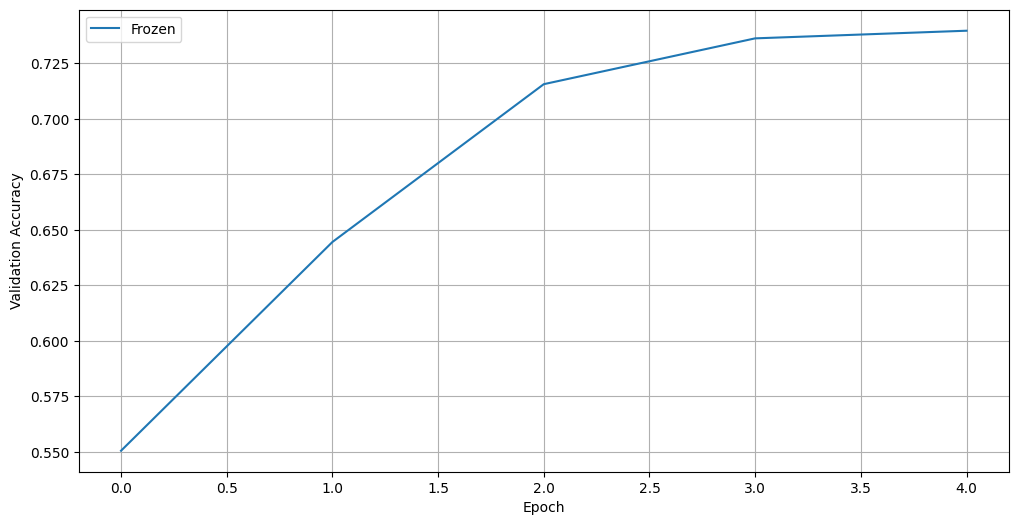

In [ ]:
plot_training_record(training_record, metric_name="val_acc")

## Fully Finetuning

In [ ]:
class FullyFinetunedBert(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = AutoModel.from_pretrained("bert-base-uncased")  # 从预训练模型加载BERT
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)  # 添加线性分类器，输出维度为1

    def forward(self, **inputs):
        feature = self.model(**inputs).last_hidden_state[:, 0, :]  # 获取特征向量
        logits = self.classifier(feature)  # 应用分类器
        return torch.sigmoid(logits).squeeze()  # 使用sigmoid激活函数并压缩维度


# 加载预训练模型
fully_fine_tuned_bert = FullyFinetunedBert()
print('-'*50)
print(fully_fine_tuned_bert)
print('-'*50)
# 检查参数数量
count_parameters(fully_fine_tuned_bert)

# 训练
training_record["Fully Fine-Tuning"] = train(
    fully_fine_tuned_bert,
    train_loader,
    val_loader,
    device,
    num_epochs=num_epochs,
    patience=patience
    )  # 对完全微调的BERT进行训练，并将训练记录保存在training_record中

--------------------------------------------------
FullyFinetunedBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
          

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.3049, train_acc 0.8589, val_loss 0.2242, val_acc 0.9174


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.1454, train_acc 0.9483, val_loss 0.2428, val_acc 0.9186


...

epoch 2: train_loss 0.0926, train_acc 0.9686, val_loss 0.2333, val_acc 0.9289


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.0618, train_acc 0.9795, val_loss 0.2685, val_acc 0.9209


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.0435, train_acc 0.9856, val_loss 0.2928, val_acc 0.9255


In [ ]:
del fully_fine_tuned_bert

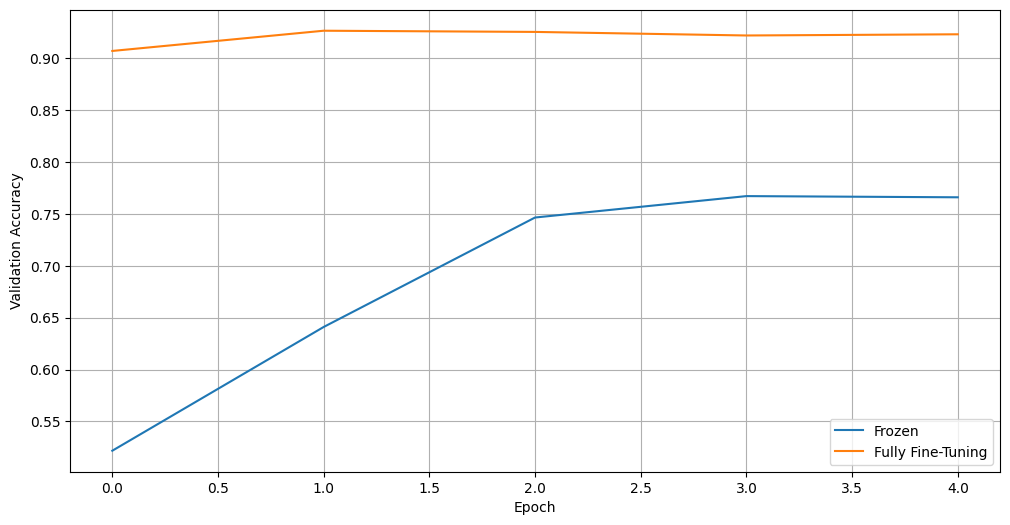

In [ ]:
#可以看到全量微调的效果非常好
plot_training_record(training_record, metric_name="val_acc")

## BitFit

BitFit（论文：BitFit: Simple Parameter-efficient Fine-tuning or Transformer-based Masked Language-models）是一种稀疏的微调方法，它训练时只更新bias的参数或者部分bias参数。

In [ ]:
class BitFitBert(nn.Module):
    def __init__(self):
        super().__init__()
        # 加载预训练模型
        self.model = AutoModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 冻结除所有偏置项之外的参数
        for name, param in self.model.named_parameters():
            if "bias" not in name:
                param.requires_grad = False

    def forward(self, **inputs):
        feature = self.model(**inputs).last_hidden_state[:, 0, :]  # 获取特征向量
        logits = self.classifier(feature)  # 应用分类器
        return torch.sigmoid(logits).squeeze()  # 使用sigmoid激活函数并压缩维度


# 加载预训练模型
bitfit_bert = BitFitBert()
print('-'*50)
print(bitfit_bert)
print('-'*50)
# 检查参数数量
count_parameters(bitfit_bert)

# 训练
training_record["BitFit"] = train(bitfit_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)  # 对BitFitBert进行训练，并将训练记录保存在training_record中

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

--------------------------------------------------
BitFitBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (Lay

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6535, train_acc 0.6128, val_loss 0.5182, val_acc 0.8154


  0%|          | 0/2105 [00:00<?, ?it/s]

...

epoch 2: train_loss 0.3336, train_acc 0.8614, val_loss 0.3174, val_acc 0.8647


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.3249, train_acc 0.8651, val_loss 0.3113, val_acc 0.8624


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.3213, train_acc 0.8670, val_loss 0.3105, val_acc 0.8624


In [ ]:
del bitfit_bert

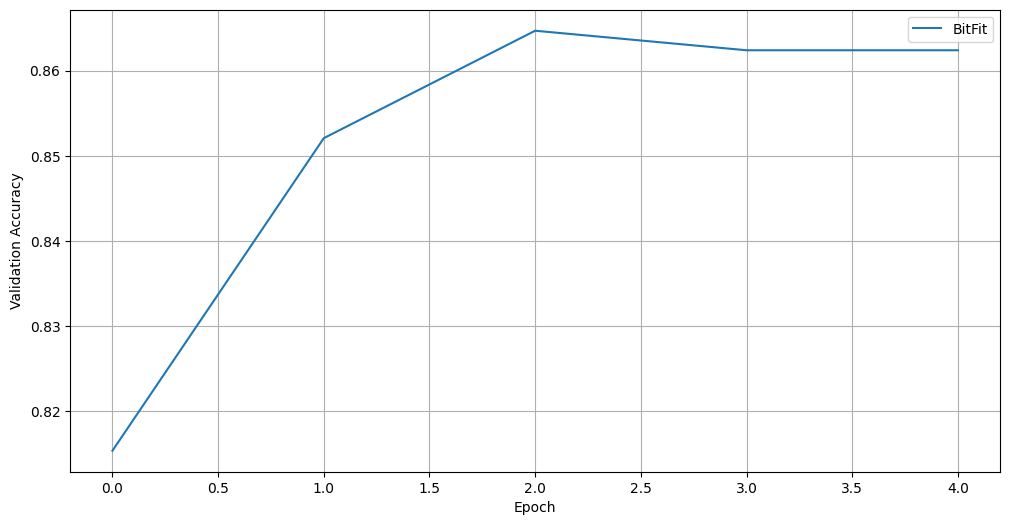

In [ ]:
#偏置项冻结后效果变差了一些
plot_training_record(training_record, metric_name="val_acc")

## P-Tuning & P-Tuning v2 & Prefix Tuning

Prefix Tuning（论文：Prefix-Tuning: Optimizing Continuous Prompts for Generation），在输入token之前构造一段任务相关的virtual tokens作为Prefix，然后训练的时候只更新Prefix部分的参数，而PLM中的其他部分参数固定。

* 针对不同的模型结构，需要构造不同的Prefix。
    * 针对自回归架构模型：在句子前面添加前缀，得到 z = [PREFIX; x; y]，合适的上文能够在固定 LM 的情况下去引导生成下文（比如：GPT3的上下文学习）。
    * 针对编码器-解码器架构模型：Encoder和Decoder都增加了前缀，得到 z = [PREFIX; x; PREFIX0; y]。Encoder端增加前缀是为了引导输入部分的编码，Decoder 端增加前缀是为了引导后续token的生成。


P-Tuning（论文：GPT Understands, Too），该方法将Prompt转换为可以学习的Embedding层，并用MLP+LSTM的方式来对Prompt Embedding进行一层处理。

相比Prefix Tuning，P-Tuning加入的可微的virtual token，但仅限于输入层，没有在每一层都加；另外，virtual token的位置也不一定是前缀，插入的位置是可选的。这里的出发点实际是把传统人工设计模版中的真实token替换成可微的virtual token。

P-Tuning v2（论文： P-Tuning v2: Prompt Tuning Can Be Comparable to Fine-tuning Universally Across Scales and Tasks），该方法在每一层都加入了Prompts tokens作为输入，而不是仅仅加在输入层，这带来两个方面的好处：

更多可学习的参数（从P-tuning和Prompt Tuning的0.01%增加到0.1%-3%），同时也足够参数高效。
加入到更深层结构中的Prompt能给模型预测带来更直接的影响。


自然语言生成 (NLG) 和 自然语言理解 (NLU)
### 区别

|方法|参数重整化| 微调参数所在层 | 适配下游任务 |
|-|-|-|-|
|P-tuning|MLP + LSTM 或者 MLP| embedding 层| 使得GPT做NLU |
|P-tuning v2|不使用| 每一层 | NLG & NLU |
|prefix tuning|MLP| 每一层 | NLG |

In [ ]:
import torch
import torch.nn as nn
prefix_tokens = nn.Parameter(torch.zeros(20, 768))
prefix_tokens = prefix_tokens.unsqueeze(0).expand(32, -1, -1) #给每个样本都增加一个（20, 768）
print(prefix_tokens.shape)

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel
import torch.nn.functional as F
import numpy as np

class PTuningBert(nn.Module):
    def __init__(self, num_virtual_tokens=20, reparameterization_type="MLP"):
        super().__init__()
        # 加载预训练模型
        self.model = AutoModel.from_pretrained("bert-base-uncased")
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 冻结除分类器层之外的参数
        for param in self.model.parameters():
            param.requires_grad = False

        hidden_size = self.model.config.hidden_size
        self.num_virtual_tokens = num_virtual_tokens #虚拟token数目
        # 定义一个可学习的参数，作为虚拟提示的初始值，其形状为(num_virtual_tokens, hidden_size)
        self.prompt = nn.Parameter(torch.zeros(self.num_virtual_tokens, hidden_size))
        print(self.prompt.shape)
        # 重新参数化,根据传入的reparameterization_type参数，初始化不同的重新参数化头部
        self.reparameterization_type = reparameterization_type
        if reparameterization_type == "MLP":
            self.mlp_head = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, hidden_size),
            )
        elif reparameterization_type == "LSTM":
            self.lstm_head = nn.LSTM(
                input_size=hidden_size,
                hidden_size=hidden_size,
                num_layers=2,
                bidirectional=True,
                batch_first=True,
            )
            self.mlp_head = nn.Sequential(
                nn.Linear(hidden_size * 2, hidden_size * 2),
                nn.ReLU(),
                nn.Linear(hidden_size * 2, hidden_size),
            )

    def forward(self, input_ids, attention_mask, **args):
        # 获取输入的批次大小
        batch_size = input_ids.size(0)
        # 将虚拟提示扩展到与输入相同批次大小 (batch_size,num_virtual_tokens,hidden_size)
        prompt = self.prompt.unsqueeze(0).expand(batch_size, -1, -1)

        # 根据选择的重新参数化类型，对虚拟提示进行处理
        if self.reparameterization_type == "MLP":
            prompt = self.mlp_head(prompt) #(batch_size,num_virtual_tokens,hidden_size)
        elif self.reparameterization_type == "LSTM":
            prompt, _ = self.lstm_head(prompt)
            prompt = self.mlp_head(prompt)

        # 将虚拟提示与输入的嵌入层输出连接，形成扩展的输入嵌入
        embedding_output = self.model.embeddings(input_ids)
        extended_inputs_embeds = torch.cat([prompt, embedding_output], dim=1) #在seq_len进行拼接
        extended_attention_mask = torch.cat([
            torch.ones(batch_size, self.num_virtual_tokens).to(input_ids.device),
            attention_mask
        ], dim=1) #掩码要同步改变，虚拟token对应的mask值都是1

        #将扩展的输入嵌入和注意力掩码输入BERT模型
        outputs = self.model(inputs_embeds=extended_inputs_embeds, attention_mask=extended_attention_mask)
        # 获取经过BERT模型处理后的特定位置的特征，即虚拟提示之后的第一个位置，等价于原来的第0个位置
        feature = outputs.last_hidden_state[:, self.num_virtual_tokens, :]

        logits = self.classifier(feature)
        return torch.sigmoid(logits).squeeze()


# 加载预训练模型
ptuning_bert = PTuningBert()
# ptuning_bert = PTuningBert(reparameterization_type='LSTM')
print('-'*50)
print(ptuning_bert)
print('-'*50)
# 记录参数数量
# def count_parameters(model):
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(ptuning_bert)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

torch.Size([20, 768])
--------------------------------------------------
PTuningBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=T

In [ ]:
for idx, (key, value) in enumerate(ptuning_bert.named_parameters()):
  print(f'key:{key}--value:{value.shape}')

key:prompt--value:torch.Size([20, 768])
key:model.embeddings.word_embeddings.weight--value:torch.Size([30522, 768])
key:model.embeddings.position_embeddings.weight--value:torch.Size([512, 768])
key:model.embeddings.token_type_embeddings.weight--value:torch.Size([2, 768])
key:model.embeddings.LayerNorm.weight--value:torch.Size([768])
key:model.embeddings.LayerNorm.bias--value:torch.Size([768])
key:model.encoder.layer.0.attention.self.query.weight--value:torch.Size([768, 768])
key:model.encoder.layer.0.attention.self.query.bias--value:torch.Size([768])
key:model.encoder.layer.0.attention.self.key.weight--value:torch.Size([768, 768])
key:model.encoder.layer.0.attention.self.key.bias--value:torch.Size([768])
key:model.encoder.layer.0.attention.self.value.weight--value:torch.Size([768, 768])
key:model.encoder.layer.0.attention.self.value.bias--value:torch.Size([768])
key:model.encoder.layer.0.attention.output.dense.weight--value:torch.Size([768, 768])
key:model.encoder.layer.0.attention.out

In [ ]:
# 进行训练
training_record["P-Tuning"] = train(ptuning_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6663, train_acc 0.5867, val_loss 0.6189, val_acc 0.6732


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.5628, train_acc 0.7160, val_loss 0.5394, val_acc 0.7443


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.5081, train_acc 0.7517, val_loss 0.5049, val_acc 0.7615


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.4897, train_acc 0.7668, val_loss 0.4927, val_acc 0.7672


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.4812, train_acc 0.7726, val_loss 0.4960, val_acc 0.7661


In [ ]:
del ptuning_bert

In [ ]:
plot_training_record(training_record, metric_name="val_acc")

In [ ]:
# 定义一个继承自nn.Module的类，用于前缀调优的BERT模型
class PrefixTuningBert(nn.Module):
    def __init__(self, num_virtual_tokens=20, prefix_projection=True):
        super().__init__()  # 调用父类的初始化方法
        # 加载预训练的BERT模型
        self.model = AutoModel.from_pretrained("bert-base-uncased")
        # 添加一个线性分类层
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 冻结预训练模型的参数，只训练分类器层
        for param in self.model.parameters():
            param.requires_grad = False

        # 前缀相关的参数
        self.num_virtual_tokens = num_virtual_tokens  # 虚拟token的数量
        self.prefix_projection = prefix_projection  # 是否使用前缀投影
        hidden_size = self.model.config.hidden_size  # 隐藏层大小
        self.num_layers = self.model.config.num_hidden_layers  # Transformer层数,12层
        self.num_attention_heads = self.model.config.num_attention_heads  # 注意力头数
        self.embed_size_per_head = hidden_size // self.num_attention_heads  # 每个头的嵌入大小

        # 如果使用前缀投影
        if self.prefix_projection:
            # 使用两层MLP来编码前缀token
            self.prefix_tokens = nn.Parameter(torch.zeros(self.num_virtual_tokens, hidden_size))
            self.transform = torch.nn.Sequential(
                torch.nn.Linear(hidden_size, hidden_size),  # 第一层MLP
                torch.nn.Tanh(),  # 使用tanh激活函数
                torch.nn.Linear(hidden_size, self.num_layers * 2 * hidden_size),  # 第二层MLP
            )
        else:
            # 不使用前缀投影，直接使用token
            self.prefix_tokens = nn.Parameter(torch.zeros(self.num_virtual_tokens, hidden_size))

    def forward(self, input_ids, attention_mask, **args):
        # 将前缀token投影并分割为key和value
        batch_size = input_ids.size(0) #获得批次大小
        prefix_tokens = self.prefix_tokens.unsqueeze(0).expand(batch_size, -1, -1)#变为（bs,num_virtual_tokens,768）
        if self.prefix_projection:
            past_key_values = self.transform(prefix_tokens) #输出的形状为(batch_size, 20, self.num_layers * 2 * hidden_size)
        else:
            past_key_values = prefix_tokens

        # 改变形状以适配Transformer的输入格式
        # print(past_key_values.shape)
        #(batch_size, self.num_layers, 2, self.num_attention_heads, -1, self.embed_size_per_head)
        past_key_values = past_key_values.view(batch_size, self.num_layers, 2, self.num_attention_heads, -1, self.embed_size_per_head)
        # print(past_key_values.shape) #shape值为torch.Size([32, 12, 2, 12, 20, 64])
        # 重新排列维度以适配Transformer的输入格式
        #(2，self.num_layers,batch_size, self.num_attention_heads, -1, self.embed_size_per_head)
        past_key_values = past_key_values.permute(2, 1, 0, 3, 4, 5)
        # 分离成多个包含key和value的元组，每个元组对应一层Transformer
        past_key_values = tuple([tuple([past_key_values[0][i], past_key_values[1][i]]) for i in range(self.num_layers)])
        # for k,v in past_key_values:
        #   print(f'k.shape{k.shape}')  #torch.Size([32, 12, 20, 64])
        #   print(f'v.shape{k.shape}')  #torch.Size([32, 12, 20, 64])
        # 修改注意力掩码，包含前缀token
        extended_attention_mask = torch.cat([
            torch.ones(batch_size, self.num_virtual_tokens).to(attention_mask.device),  # 前缀的注意力掩码
            attention_mask
            ], dim=1)

        # 将数据输入到BERT模型中,传入past_key_values
        outputs = self.model(input_ids, extended_attention_mask, past_key_values=past_key_values)

        feature = outputs.last_hidden_state[:, 0, :]  # 获取[CLS] token的特征表示

        # 使用分类层进行分类
        logits = self.classifier(feature)

        # 返回sigmoid激活后的logits
        return torch.sigmoid(logits).squeeze()

# 创建前缀调优BERT模型实例
prefix_tuning_bert = PrefixTuningBert()
# print(prefix_tuning_bert)
# 计算模型参数数量
count_parameters(prefix_tuning_bert)



Total Parameters:	 124.26M
Frozen Parameters:	 109.48M
Trainable Parameters:	  14.78M	11.89%


In [ ]:
768*12*2 #2代表key和value

In [ ]:
12*64

In [ ]:
# 训练模型，这里的train函数和train_loader、val_loader等变量需要在其他地方定义
# num_epochs和patience变量也需要在其他地方定义
training_record["Prefix Tuning"] = train(prefix_tuning_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6882, train_acc 0.5200, val_loss 0.6718, val_acc 0.5528


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.3871, train_acc 0.8306, val_loss 0.3193, val_acc 0.8578


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.3035, train_acc 0.8720, val_loss 0.2971, val_acc 0.8693


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.2896, train_acc 0.8777, val_loss 0.2933, val_acc 0.8750


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.2864, train_acc 0.8797, val_loss 0.2934, val_acc 0.8773


In [ ]:
del prefix_tuning_bert

In [ ]:
# !cp -r ~/.cache/huggingface/hub/models--bert-base-uncased .

In [ ]:
!pwd

In [ ]:
plot_training_record(training_record, metric_name="val_acc")

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer

class PTuningV2Bert(nn.Module):
    def __init__(self, num_virtual_tokens=20, prefix_projection=True):
        super().__init__()
        # 加载预训练的BERT模型
        self.model = AutoModel.from_pretrained("bert-base-uncased")
        # 添加一个线性分类层
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 冻结预训练模型的参数，只训练分类器层
        for param in self.model.parameters():
            param.requires_grad = False

        # 前缀相关的参数
        self.num_virtual_tokens = num_virtual_tokens
        self.prefix_projection = prefix_projection #开启前缀投影
        hidden_size = self.model.config.hidden_size #768
        self.num_layers = self.model.config.num_hidden_layers #层数，12层
        self.num_attention_heads = self.model.config.num_attention_heads #注意力头数
        self.embed_size_per_head = hidden_size // self.num_attention_heads #768//12 =64

        # P-Tuning v2 的前缀嵌入
        self.prefix_embeddings = nn.Embedding(self.num_virtual_tokens, hidden_size)
        nn.init.uniform_(self.prefix_embeddings.weight, -0.1, 0.1)

        if self.prefix_projection:
            # 使用两层MLP来编码前缀token
            self.prefix_projection_layer = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.Tanh(),
                nn.Linear(hidden_size, self.num_layers * 2 * hidden_size)
            )

    def forward(self, input_ids, attention_mask, **args):
        batch_size = input_ids.size(0)
        prefix_tokens = torch.arange(self.num_virtual_tokens, device=input_ids.device).unsqueeze(0).expand(batch_size, -1)
        prefix_embeddings = self.prefix_embeddings(prefix_tokens) #得到num_virtual_tokens,长度为hidden_size的密集向量

        if self.prefix_projection:
            past_key_values = self.prefix_projection_layer(prefix_embeddings) #变多
        else:
            past_key_values = prefix_embeddings

        # 改变形状以适配Transformer的输入格式，（bs,num_layers,2,12,num_virtual_tokens,64）
        past_key_values = past_key_values.view(batch_size, self.num_layers, 2, self.num_attention_heads, -1, self.embed_size_per_head)
        past_key_values = past_key_values.permute(2, 1, 0, 3, 4, 5) #要变为这个形状
        past_key_values = tuple([tuple([past_key_values[0][i], past_key_values[1][i]]) for i in range(self.num_layers)]) #接口要求

        # 修改注意力掩码，包含前缀token
        extended_attention_mask = torch.cat([
            torch.ones(batch_size, self.num_virtual_tokens).to(attention_mask.device),  # 前缀的注意力掩码
            attention_mask
        ], dim=1)

        # 将数据输入到BERT模型中
        outputs = self.model(input_ids, attention_mask=extended_attention_mask, past_key_values=past_key_values)

        feature = outputs.last_hidden_state[:, 0, :]  # 获取[CLS] token的特征表示

        # 使用分类层进行分类
        logits = self.classifier(feature)

        # 返回sigmoid激活后的logits
        return torch.sigmoid(logits).squeeze()

# 创建P-Tuning v2 BERT模型实例
p_tuning_v2_bert = PTuningV2Bert()
print(p_tuning_v2_bert)

# # 计算模型参数数量
# def count_parameters(model):
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total trainable parameters: {count_parameters(p_tuning_v2_bert)}')


training_record["P-Tuning v2"] = train(p_tuning_v2_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)


PTuningV2Bert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6691, train_acc 0.5714, val_loss 0.5593, val_acc 0.8188


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.3491, train_acc 0.8576, val_loss 0.3194, val_acc 0.8704


...

epoch 2: train_loss 0.2991, train_acc 0.8749, val_loss 0.2948, val_acc 0.8773


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.2911, train_acc 0.8769, val_loss 0.2871, val_acc 0.8830


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.2875, train_acc 0.8787, val_loss 0.2857, val_acc 0.8842


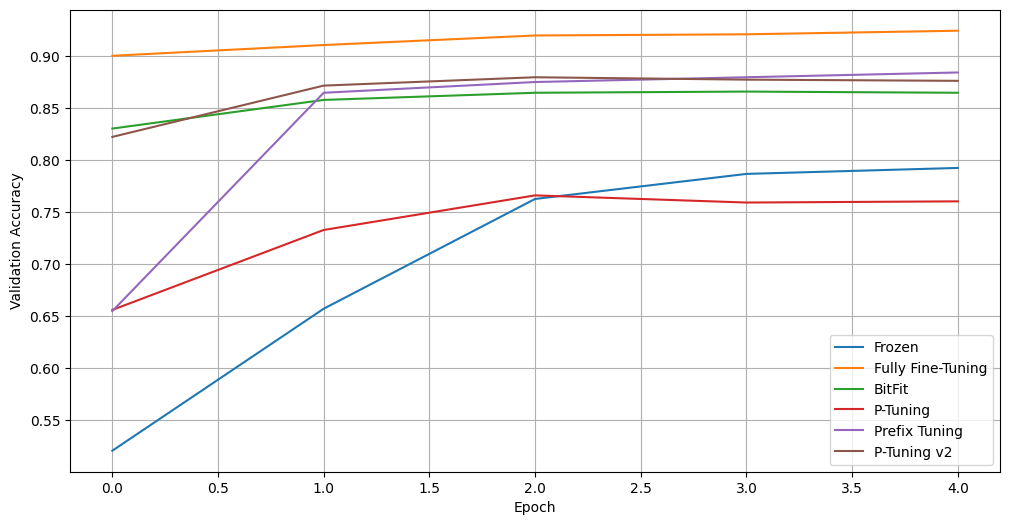

In [ ]:
plot_training_record(training_record, metric_name="val_acc")

## LoRA

LoRA（论文：LoRA: LOW-RANK ADAPTATION OF LARGE LANGUAGE MODELS），该方法的核心思想就是通过低秩分解来模拟参数的改变量，从而以极小的参数量来实现大模型的间接训练。

在涉及到矩阵相乘的模块，在原始的PLM旁边增加一个新的通路，通过前后两个矩阵A,B相乘，第一个矩阵A负责降维，第二个矩阵B负责升维，中间层维度为r，从而来模拟所谓的本征秩（intrinsic rank）。

rank的作用：
rank代表低秩矩阵的秩，即线性变换矩阵A和B的输出特征数量。在LoRA中，原始的高维特征通过线性变换A被映射到一个低维空间（rank维），然后再通过另一个线性变换B映射回原始特征空间。较低的rank值意味着更少的参数需要更新，从而降低了模型复杂度和计算成本。

lora_alpha的作用：
lora_alpha是一个缩放因子，用于调整LoRA输出的贡献。它通过除以rank来计算得到scaling，这个缩放因子被用于控制低秩空间中的特征对最终输出的贡献度。较大的lora_alpha值会增加LoRA特征的影响力，而较小的值则会减少其影响。

In [ ]:
for layer in bert_model.encoder.layer:
  print(type(layer))
  print('-'*50)

<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'tr

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel
# 其他必要的导入语句可能在这里，例如用于训练的优化器、损失函数等。

# 定义LoRALayer类，它继承自PyTorch的nn.Module
class LoRALayer(nn.Module):
    # 初始化函数
    def __init__(self, module: nn.Module, rank: int = 1, lora_alpha: int = 1):
        # 调用父类的初始化函数
        super().__init__()
        # 确保输入的rank是正整数
        assert isinstance(rank, int) and rank > 1, "Lora rank should be a positive integer"

        # 计算缩放因子
        self.scaling = lora_alpha / rank
        # 存储传入的模块
        self.module = module
        # 定义从输入特征到rank维空间的线性变换A
        self.A = nn.Linear(module.in_features, rank, bias=False)
        # 定义从rank维空间到输出特征的线性变换B
        self.B = nn.Linear(rank, module.out_features, bias=False)
        # 使用Kaiming均匀初始化方法初始化A的权重,超参可选
        nn.init.kaiming_uniform_(self.A.weight, a=5 ** 0.5)
        # 将B的权重初始化为0，超参可选
        nn.init.zeros_(self.B.weight)
        # 将A和B移动到与模块权重相同的设备上
        self.A.to(device=module.weight.device)
        self.B.to(device=module.weight.device)

    # 前向传播函数
    def forward(self, inputs, *args, **kwargs):
        # 首先通过原始模块进行前向传播
        with torch.no_grad():  # 确保这个操作不会影响梯度计算
            outputs = self.module(inputs, *args, **kwargs)
        # 计算LoRA的输出并加到原始模块的输出上
        return outputs + self.B(self.A(inputs)) * self.scaling

# 定义LoRABert类，它也继承自PyTorch的nn.Module
class LoRABert(nn.Module):
    # 初始化函数
    def __init__(self, rank=8, lora_alpha=32):
        # 调用父类的初始化函数
        super().__init__()
        # 加载预训练的BERT模型
        self.model = AutoModel.from_pretrained("bert-base-uncased")
        # 应用LoRA技术到BERT模型的查询投影和键投影
        self._apply_lora(rank=rank, lora_alpha=lora_alpha)
        # 定义一个线性分类器，用于最后的任务分类
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

    # 应用LoRA到BERT模型的辅助函数,把self.model换掉了
    def _apply_lora(self, rank, lora_alpha):
        # 冻结预训练模型的参数
        for param in self.model.parameters():
            param.requires_grad = False
        # 对BERT模型中的每一层应用LoRA，children()可以拿到每层的层对象,也可以换V和O，这就是超参
        for layer in self.model.encoder.layer.children():
            layer.attention.self.query = LoRALayer(layer.attention.self.query, rank=rank, lora_alpha=lora_alpha) #替换掉对应的层
            layer.attention.self.key = LoRALayer(layer.attention.self.key, rank=rank, lora_alpha=lora_alpha)

    # 前向传播函数
    def forward(self, input_ids, attention_mask, token_type_ids):
        # 通过BERT模型进行前向传播
        outputs = self.model(input_ids, attention_mask, token_type_ids)
        # 提取[CLS]标记的表示作为特征
        feature = outputs.last_hidden_state[:, 0, :]
        # 使用分类器生成logits
        logits = self.classifier(feature)
        # 应用sigmoid激活函数得到最终的输出
        return torch.sigmoid(logits).squeeze()

# 实例化LoRABert模型
lora_bert = LoRABert(rank=8,lora_alpha=32)
print(lora_bert)
# 假设count_parameters是一个函数，用于计算并打印模型的参数数量
count_parameters(lora_bert)



LoRABert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): LoRALayer(
                (module): Linear(in_features=768, out_features=768, bias=True)
                (A): Linear(in_features=768, out_features=8, bias=False)
                (B): Linear(in_features=8, out_features=768, bias=False)
              )
              (key): LoRALayer(
                (module): Linear(in_features=768, out_features=768, bias=True)
                (A): Linear(in_features=768, out_features=8, bias=False)
                (B): 

In [ ]:
# 假设train是一个函数，用于训练模型
# training_record是一个字典，用于记录不同模型的训练结果
# train_loader和val_loader是数据加载器，device是指定的设备（CPU或GPU）
# num_epochs是训练的轮数，patience是早停的耐心轮数
training_record["LoRA"] = train(lora_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6503, train_acc 0.6292, val_loss 0.4693, val_acc 0.8521


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.3795, train_acc 0.8526, val_loss 0.3267, val_acc 0.8681


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.3274, train_acc 0.8649, val_loss 0.3047, val_acc 0.8842


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.3128, train_acc 0.8710, val_loss 0.2923, val_acc 0.8853


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.3098, train_acc 0.8716, val_loss 0.2915, val_acc 0.8853


In [ ]:
del lora_bert

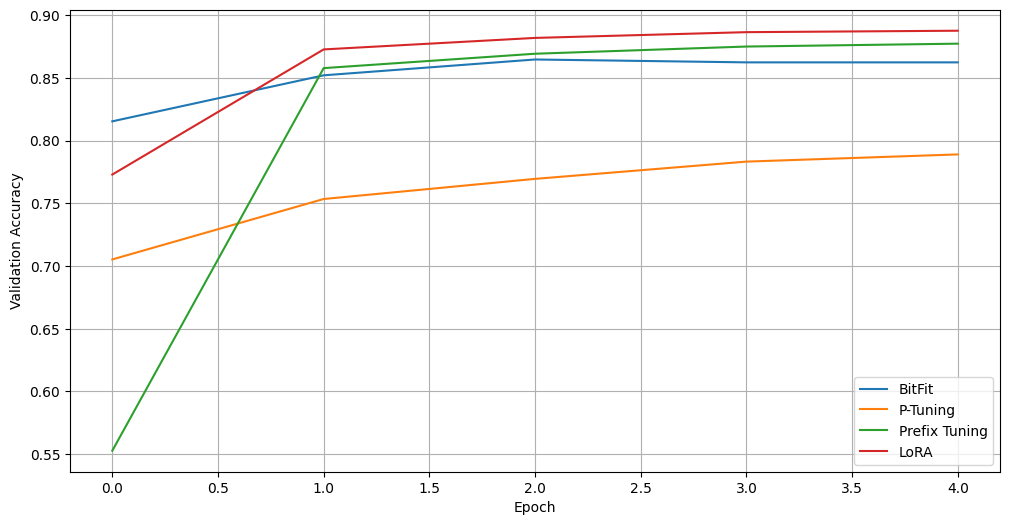

In [ ]:
plot_training_record(training_record, metric_name="val_acc")

## Adapter Tuning

Adapter Tuning（论文：Parameter-Efficient Transfer Learning for NLP），该方法设计了Adapter结构，并将其嵌入Transformer的结构里面，针对每一个Transformer层，增加了两个Adapter结构(分别是多头注意力的投影之后和第二个feed-forward层之后)，在训练时，固定住原来预训练模型的参数不变，只对新增的 Adapter 结构和 Layer Norm 层进行微调，从而保证了训练的高效性。

In [ ]:
class AdapterLayer(nn.Module):
    def __init__(self, input_size, adapter_size):
        super().__init__()
        # 第一个线性层，将输入特征从 input_size 维度降低到 adapter_size 维度
        self.down_project = nn.Linear(input_size, adapter_size)
        # ReLU 激活函数
        self.nolinearity = nn.ReLU()
        # 第二个线性层，将适配器层的特征从 adapter_size 维度恢复到原始维度
        self.up_project = nn.Linear(adapter_size, input_size)

    def forward(self, x):
        # 适配器层的前向传播
        return self.up_project(self.nolinearity(self.down_project(x)))


class BertSelfOutput(nn.Module):
    # 自注意力层的输出部分
    def __init__(self, config, adapter_size):
        super().__init__()
        # 原始的全连接层
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        # 原始的LayerNorm(层归一化) 层
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        # 原始的 Dropout 层
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        # 插入的适配器层
        self.adapter = AdapterLayer(config.hidden_size, adapter_size)

    def forward(self, hidden_states: torch.Tensor, input_tensor: torch.Tensor) -> torch.Tensor:
        # 自注意力层的输出前向传播
        hidden_states = self.dense(hidden_states)
        hidden_states = self.dropout(hidden_states)
        hidden_states = self.adapter(hidden_states) #把自己写的adapter给串进去
        hidden_states = self.LayerNorm(hidden_states + input_tensor) #加号代表残差连接
        return hidden_states

class BertOutput(nn.Module):
    # 输出层
    def __init__(self, config, adapter_size):
        super().__init__()
        # 原始的全连接层
        # print(config.intermediate_size) #3072
        self.dense = nn.Linear(config.intermediate_size, config.hidden_size)
        # LayerNorm 层
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        # Dropout 层
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        # 插入的适配器层
        self.adapter = AdapterLayer(config.hidden_size, adapter_size)

    def forward(self, hidden_states: torch.Tensor, input_tensor: torch.Tensor) -> torch.Tensor:
        # 输出层的前向传播
        hidden_states = self.dense(hidden_states)
        hidden_states = self.dropout(hidden_states)
        hidden_states = self.adapter(hidden_states) #把adapter放入原有的层中间
        hidden_states = self.LayerNorm(hidden_states + input_tensor)
        return hidden_states


class AdapterBert(nn.Module):
    def __init__(self, adapter_size=64):
        super().__init__()
        # 加载预训练的BERT模型
        self.model = AutoModel.from_pretrained("bert-base-uncased")
        # 获取预训练模型的状态字典，为什么要提前保存，是因为原有的层被覆盖的问题
        pretrained_state_dict = self.model.state_dict()
        print(self.model.config)
        # 添加一个线性分类器
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 为模型的每层应用适配器，把模型对应的BertSelfOutput和BertOutput覆盖
        self._apply_adapter(adapter_size=adapter_size)

        # 修改预训练状态字典，将适配器层的参数加入
        for name, param in self.model.named_parameters():
            if "adapter" in name:
                pretrained_state_dict[name] = param #把adapter层放进去
        # 加载修改后的状态字典
        self.model.load_state_dict(pretrained_state_dict)

        # 冻结除适配器层以外的所有参数
        for name, param in self.model.named_parameters():
            if "adapter" not in name:
                param.requires_grad = False

        # 删除不再使用的预训练状态字典
        del pretrained_state_dict

    def _apply_adapter(self, adapter_size):
        # 为BERT模型的每层应用适配器层，总计12层
        for layer in self.model.encoder.layer:
            layer.attention.output = BertSelfOutput(self.model.config, adapter_size) #BertSelfOutput输出层重写,名字是完全对应的
            layer.output = BertOutput(self.model.config, adapter_size) #BertOutput层重写，名字是完全对应的

    def forward(self, input_ids, attention_mask, token_type_ids):
        # 模型的前向传播
        outputs = self.model(input_ids, attention_mask, token_type_ids)
        # 提取[CLS]标记的表示作为特征
        feature = outputs.last_hidden_state[:, 0, :]
        # 使用分类器生成logits
        logits = self.classifier(feature)
        # 应用sigmoid激活函数得到最终的输出
        return torch.sigmoid(logits).squeeze()


# 实例化适配器BERT模型
adapter_bert = AdapterBert(adapter_size=64)
print('-'*50)
print(adapter_bert)
print('-'*50)
# 计算模型参数
count_parameters(adapter_bert)



BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.53.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

--------------------------------------------------
AdapterBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (drop

In [ ]:
# 训练模型
training_record["Adapter Tuning"] = train(adapter_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6289, train_acc 0.5918, val_loss 0.4954, val_acc 0.7718


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.3997, train_acc 0.8201, val_loss 0.4387, val_acc 0.8073


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.3615, train_acc 0.8398, val_loss 0.4335, val_acc 0.8062


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.3460, train_acc 0.8477, val_loss 0.4224, val_acc 0.8108


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.3395, train_acc 0.8517, val_loss 0.4236, val_acc 0.8085


In [ ]:
del adapter_bert

## Plot

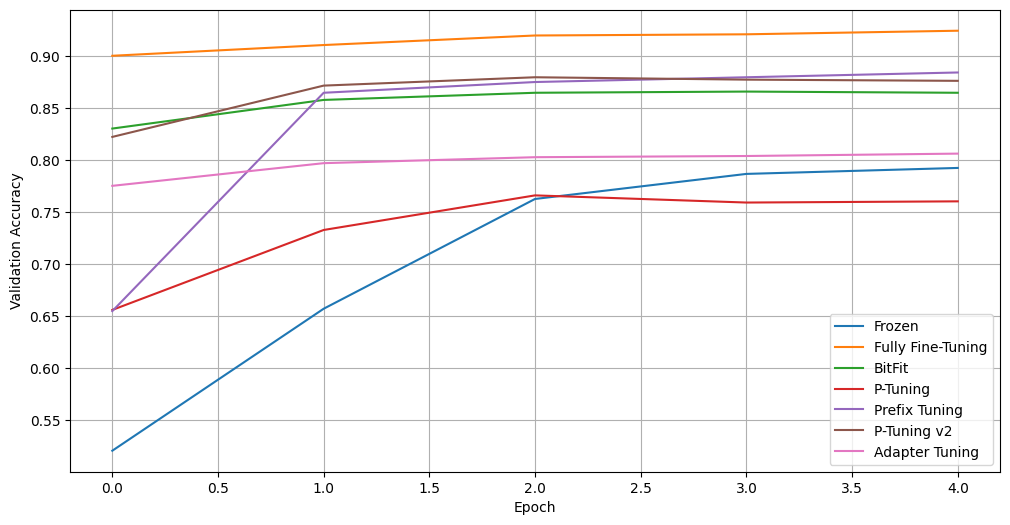

In [ ]:

plot_training_record(training_record, metric_name="val_acc")